# Entendimento dos Dados (EDA)

# Importando bibliotecas

- Todas as bibliotecas estão disponíveis para download em projeto-final-rh-analytics/techcorp_attrition/requirements.txt
- O ambiente virtual foi instalado com a versão mais recente do python - 3.14.5

### Passos para criação do Kernel VSCode
Rode os seguintes comandos - supondo que já realizou a criação do ambiente virtual
- Ativar o ambiente virtual (se ainda não estiver ativo): .venv\Scripts\activate
- Instalar o ipykernel no ambiente: pip install ipykernel
- Registrar o kernel no Jupyter: python -m ipykernel install --user --name=XXnome-venvXX --display-name "Python xx.xx.xx (meu-projeto)"
- Verificar se o kernel foi registrado: jupyter kernelspec list
- Remover o kernel quando não precisar mais: jupyter kernelspec remove meu-projeto


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")

# 1 - Carregamento dos dados

In [3]:
# Carregando o dataset
df = pd.read_csv('../data/raw/ibm_hr_analytics_sintetico.csv')

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dimensões do dataset: 1000000 linhas x 35 colunas


# 2 - Análise Exploratória Inicial

In [4]:
# Primeira visualização
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,No,Travel_Rarely,590,Research & Development,19,1,Other,1,1,4,Female,73,3,3,Research Director,3,Divorced,12378,24652,1,Y,Yes,18,3,1,80,3,33,2,2,29,11,11,1
1,46,No,Travel_Rarely,1441,Human Resources,5,1,Life Sciences,1,2,4,Male,88,4,1,Laboratory Technician,3,Married,9987,15406,2,Y,Yes,12,3,1,80,2,37,3,3,37,6,5,16
2,32,Yes,Travel_Frequently,748,Research & Development,2,3,Medical,1,3,4,Male,89,4,2,Sales Representative,2,Divorced,1276,16073,1,Y,No,15,3,2,80,0,26,1,1,16,3,15,12
3,60,No,Travel_Rarely,1311,Human Resources,3,4,Life Sciences,1,4,2,Female,41,1,4,Research Scientist,2,Single,1807,23260,3,Y,No,17,3,4,80,2,29,3,2,29,17,6,9
4,25,No,Non-Travel,144,Sales,10,4,Life Sciences,1,5,4,Male,66,1,2,Manager,3,Married,14635,2614,1,Y,No,12,3,2,80,1,22,6,4,6,2,6,14


#### Describe do dataframe

**Describe para variáveis numéricas**

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000000.0,41.000062,13.564537,18.0,29.00,41.0,53.00,64.0
DailyRate,1000000.0,799.932980,404.415724,100.0,450.00,800.0,1150.00,1499.0
DistanceFromHome,1000000.0,15.021016,8.365798,1.0,8.00,15.0,22.00,29.0
Education,1000000.0,2.500602,1.118390,1.0,1.00,3.0,4.00,4.0
EmployeeCount,1000000.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1000000.0,500000.500000,288675.278932,1.0,250000.75,500000.5,750000.25,1000000.0
EnvironmentSatisfaction,1000000.0,2.498100,1.118145,1.0,1.00,2.0,3.00,4.0
HourlyRate,1000000.0,64.486837,20.202957,30.0,47.00,64.0,82.00,99.0
JobInvolvement,1000000.0,2.499435,1.117884,1.0,1.00,2.0,3.00,4.0
JobLevel,1000000.0,2.999672,1.413922,1.0,2.00,3.0,4.00,5.0


**Describe para variáveis categóricas**

In [6]:
df.describe(include='object').T

,count,unique,top,freq
Attrition,1000000,2,No,839867
BusinessTravel,1000000,3,Travel_Frequently,333665
Department,1000000,3,Sales,333749
EducationField,1000000,6,Other,167152
Gender,1000000,2,Female,500211
JobRole,1000000,9,Human Resources,111726
MaritalStatus,1000000,3,Married,333467
Over18,1000000,1,Y,1000000
OverTime,1000000,2,No,719728


#### Validações adicionais

Essa análise garante verificar:

- tipagem dos dados
- quantidade de valores únicos
- valores ausentes
- porcentagem de valores ausentes
- quantidade de duplicatas

In [7]:
def dataframe_overview(data):
    overview = pd.DataFrame({
        "data_type": data.dtypes.astype(str),
        "qtd_value_unique": data.nunique(),
        "missing": data.isna().sum(),
        "missing_pct": data.isna().mean() * 100,
        "duplicated_values": [data[col].duplicated().sum() for col in data.columns]
    })
    return overview.sort_values(["missing_pct", "qtd_value_unique"], ascending=[False, True])

overview = dataframe_overview(df)
overview

,data_type,qtd_value_unique,missing,missing_pct,duplicated_values
EmployeeCount,int64,1,0,0.0,999999
Over18,str,1,0,0.0,999999
StandardHours,int64,1,0,0.0,999999
Attrition,str,2,0,0.0,999998
Gender,str,2,0,0.0,999998
OverTime,str,2,0,0.0,999998
PerformanceRating,int64,2,0,0.0,999998
BusinessTravel,str,3,0,0.0,999997
Department,str,3,0,0.0,999997
MaritalStatus,str,3,0,0.0,999997


##### **Variáveis desnecessárias**:

Com base nas análises anteriores, podemos observar algumas variáveis que são irrelevantes para predição do modelo.:
- EmployeeCount: valor 1 para todos, não agrega informação
- StandardHours: valor 80 para todos, não agrega informação
- Over18: valor "Y" para todos, não agrega informação
- EmployeeNumber: Identificador único, não é uma feature. A presença de identificadores únicos pode levar ao data leakage, onde o modelo memoriza resultados do conjunto de treino que não se repetirão no conjunto de validação ou produção, mascarando a real eficácia do algoritmo.

Estamos realizando uma copy do dataframe original e salvando na variável df_raw

In [8]:
# Retirando colunas desnecessárias
df_raw = df.copy()
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])
 
print(df.shape)

(1000000, 31)


#### Criando variável binária para Attrition

In [9]:
df_eda = df.copy()
df_eda["AttritionFlag"] = (df_eda["Attrition"] == "Yes").astype(int)

#### Peso da target

In [10]:
# Quantidade de registros agrupando por Yes e No
print(df_eda['AttritionFlag'].value_counts())
print()
# Porcentagem dos registros agrupando por Yes e No
print(df_eda['AttritionFlag'].value_counts(normalize=True))
print()
# Confirmando o resultado da taxa de atrito
attrition_counts = df_eda['Attrition'].value_counts()
print(f"\nTaxa de atrito: {(attrition_counts['Yes'] / len(df)) * 100:.2f}%")

AttritionFlag
0    839867
1    160133
Name: count, dtype: int64

AttritionFlag
0    0.839867
1    0.160133
Name: proportion, dtype: float64


Taxa de atrito: 16.01%


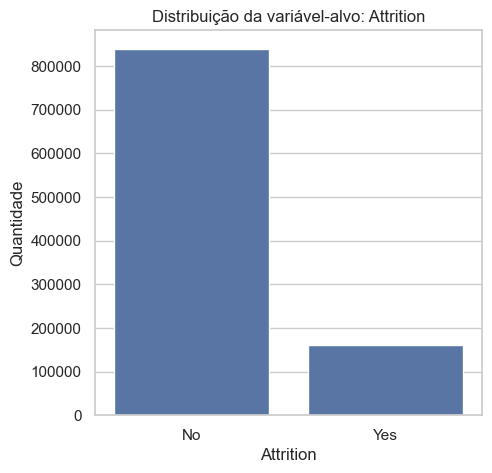

In [11]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df_eda, x="Attrition")
plt.title("Distribuição da variável-alvo: Attrition")
plt.xlabel("Attrition")
plt.ylabel("Quantidade")
plt.savefig('../reports/distribuicao_variavel_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

**A target está desbalanceada**

Definimos a coluna Attrition como target, pois o modelo indica se o colaborador teve um desligamento ou não. Como observado nos dados e gráficos anteriores, há um desbalanceamento considerável entre as classes. Conforme observado, o conjunto de dados apresenta um desbalanceamento significativo, com ~84% dos funcionários mantendo o vínculo e apenas 16% registrando a saída.

|Attrition | % |
|--|--|
|No | 83,99% |
|Yes | 16,01% |

Ao desenvolver o modelo, este desbalanceamento exige atenção redobrada. Caso não seja tratado, o algoritmo terá dificuldade em prever a classe minoritária ('Yes'). Esse ponto é crucial e alinha-se ao que foi levantado na etapa de Business Understanding que **```para a empresa, o prejuízo é maior quando o modelo prevê que o funcionário permanecerá, mas ele acaba saindo (falso negativo).```**

**Objetivo**

Nosso objetivo é otimizar o modelo para minimizar esses erros de FN (falso negativo), aumentando a assertividade na identificação de colaboradores em risco de desligamento, tendo como foco os verdadeiros positivos.

- Nessa etapa, faremos a separação entre variáveis numéricas de categóricas. Essa prática ajuda na identificação dos gráficos corretos para cada

In [12]:
feature_cols = [c for c in df_eda.columns if c not in ["Attrition", "AttritionFlag"]]

num_cols = df_eda[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = df_eda[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Categóricas: {cat_cols}")
print(f"Numéricas: {num_cols}")

Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [13]:
print(f'Total de variáveis categóricas: {len(cat_cols)}')
print(f'Total de variáveis numéricas: {len(num_cols)}')

Total de variáveis categóricas: 7
Total de variáveis numéricas: 23


**Variáveis Ordinais Disfarçadas de Número**

Dentre as 23 variáveis numéricas identificadas, as seguintes são **escalas ordinais**
— possuem ordem, mas a distância entre os valores não é necessariamente igual:

| Variável | Valores | O que significa |
|---|---|---|
| Education | 1-5 | 1=Abaixo da faculdade … 5=Doutorado |
| EnvironmentSatisfaction | 1-4 | 1=Baixo … 4=Muito Alto |
| JobInvolvement | 1-4 | 1=Baixo … 4=Muito Alto |
| JobLevel | 1-5 | Nível hierárquico |
| JobSatisfaction | 1-4 | 1=Baixo … 4=Muito Alto |
| PerformanceRating | 1-4 | 1=Baixo … 4=Excelente |
| RelationshipSatisfaction | 1-4 | 1=Baixo … 4=Muito Alto |
| StockOptionLevel | 0-3 | Nível de opções de ações |
| WorkLifeBalance | 1-4 | 1=Ruim … 4=Excelente |

In [14]:
# Numéricas contínuas reais
num_continuas = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                 'YearsWithCurrManager']

# Escalas ordinais disfarçadas de número
num_ordinais = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

print(f"Contínuas: {len(num_continuas)}")
print(f"Ordinais:  {len(num_ordinais)}")

Contínuas: 14
Ordinais:  9


Realizando uma amostragem estratificada com as mesmas proporções da coluna 'Attrition'. Uma boa prática para que a geração das visualizaações não fique pesada

In [15]:
df_sample = (
    df_eda.groupby('Attrition', group_keys=False)
    .apply(lambda x: x.sample(frac=0.1, random_state=42), include_groups=False)
    .reset_index(drop=False)  # mantém o índice original que contém o Attrition
)

# Renomear se necessário
df_sample = df_eda.loc[
    df_eda.groupby('Attrition', group_keys=False)
    .apply(lambda x: x.sample(frac=0.05, random_state=42), include_groups=False)
    .index
]

print(f"Tamanho da amostra: {df_sample.shape[0]}")
print(f"\nProporção original:")
print(df_eda['Attrition'].value_counts(normalize=True))
print(f"\nProporção na amostra:")
print(df_sample['Attrition'].value_counts(normalize=True))

Tamanho da amostra: 50000

Proporção original:
Attrition
No     0.839867
Yes    0.160133
Name: proportion, dtype: float64

Proporção na amostra:
Attrition
No     0.83986
Yes    0.16014
Name: proportion, dtype: float64


Validando distribuição da amostra

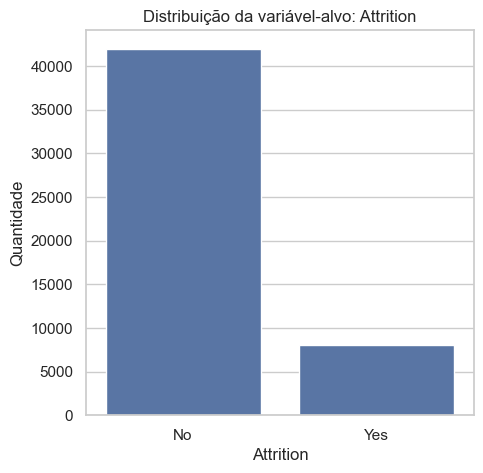

In [16]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df_sample, x="Attrition")
plt.title("Distribuição da variável-alvo: Attrition")
plt.xlabel("Attrition")
plt.ylabel("Quantidade")
plt.savefig('../reports/distribuicao_variavel_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Análise visual e levantamento de hipóteses

## **Definindo Hipóteses**

H0 (hipótese nula):

A variável não tem relação com o funcionário entrar em attrition
- Qualquer diferença observada é apenas acaso/coincidência

H1 (hipótese alternativa):
A variável tem relação com o funcionário entrar em attrition
- A diferença observada é real

## 3.1 - Distribuição das Variáveis Numéricas

In [17]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cria pasta se não existir
output_dir = "../reports/distribuicao_variaveis_continuas"
os.makedirs(output_dir, exist_ok=True)

def analise_variaveis_continuas(df_amostra, variaveis):
    print('Percorrendo todas as variáveis')

    for col in variaveis:

        # Cria uma nova figura para cada variável
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Histograma
        sns.histplot(
            data=df_amostra,
            x=col,
            hue="Attrition",
            kde=True,
            ax=axes[0],
            palette={"Yes": "#da1600", "No": "#00ff6a"}
        )
        axes[0].set_title(f"{col} — Distribuição")

        # Boxplot
        sns.boxplot(
            data=df_amostra,
            x="Attrition",
            y=col,
            ax=axes[1],
            palette={"Yes": "#da1600", "No": "#00ff6a"}
        )
        axes[1].set_title(f"{col} — por Attrition")

        plt.tight_layout()

        # Salva a imagem usando o nome da variável
        plt.savefig(
                    f"{output_dir}/{col}.png",
                    dpi=150,
                    bbox_inches="tight"
                )

        plt.show()

        # Fecha a figura para liberar memória
        plt.close(fig)

Percorrendo todas as variáveis


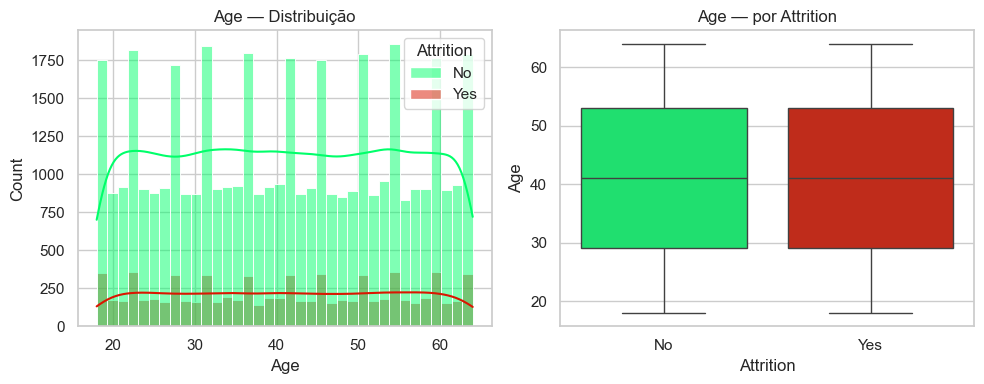

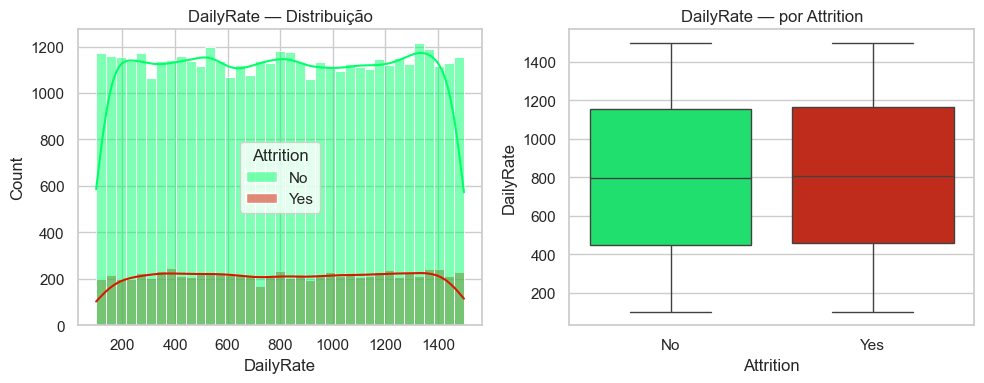

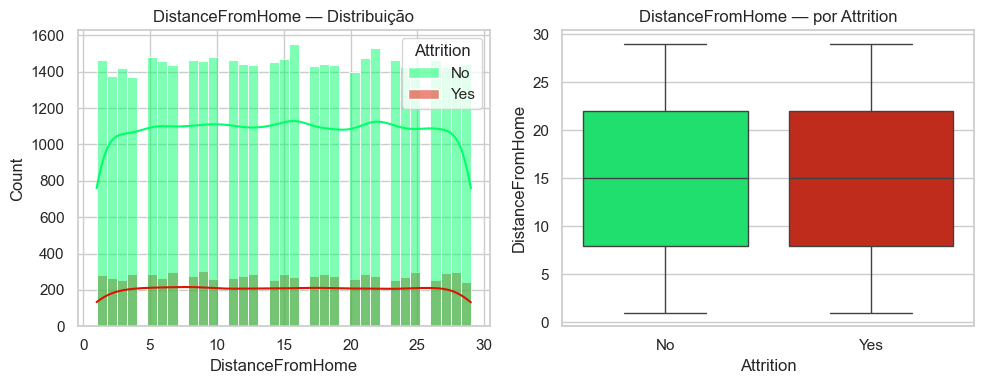

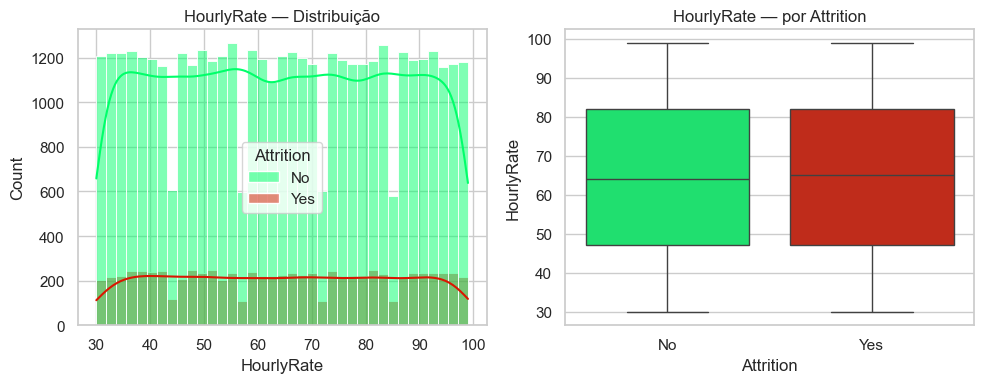

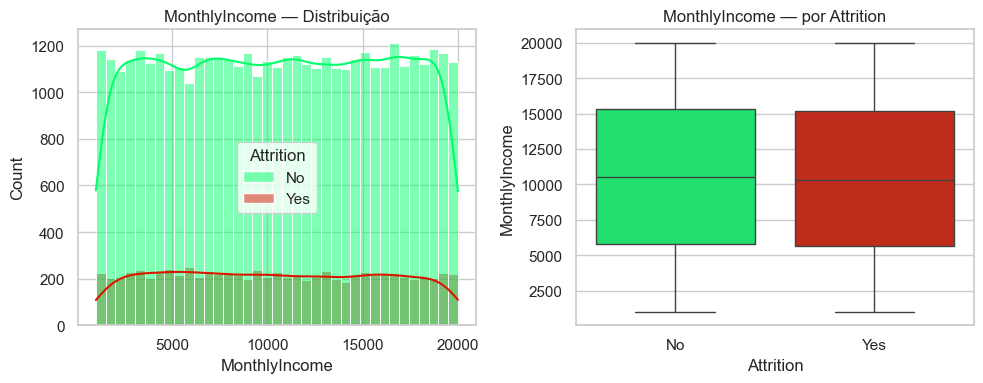

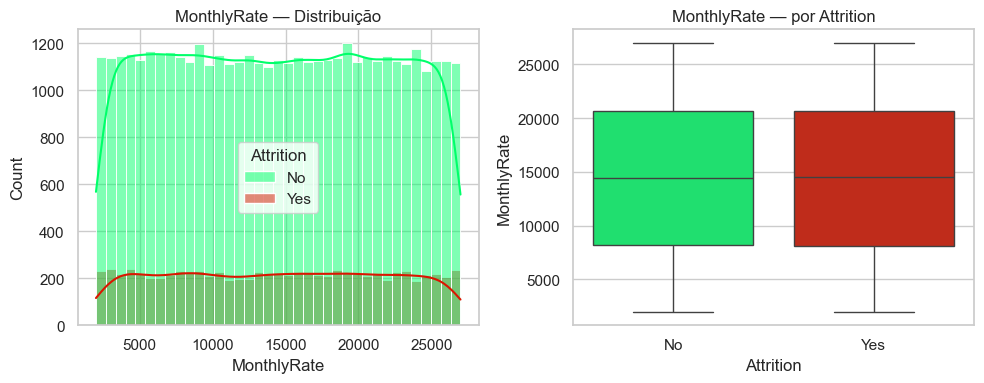

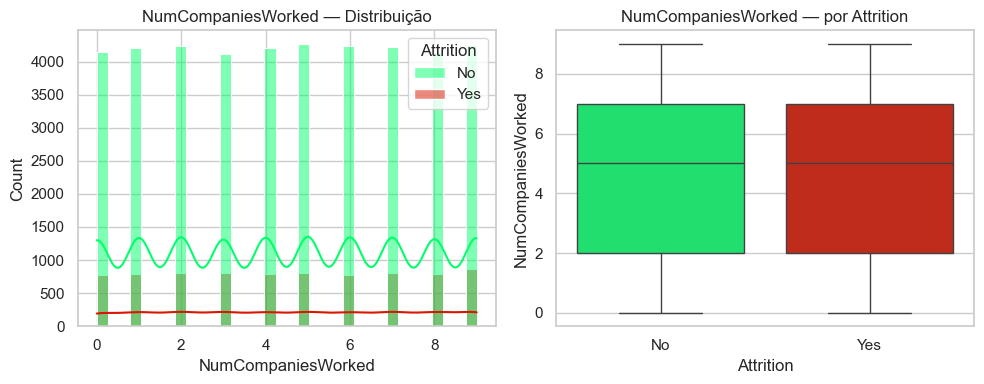

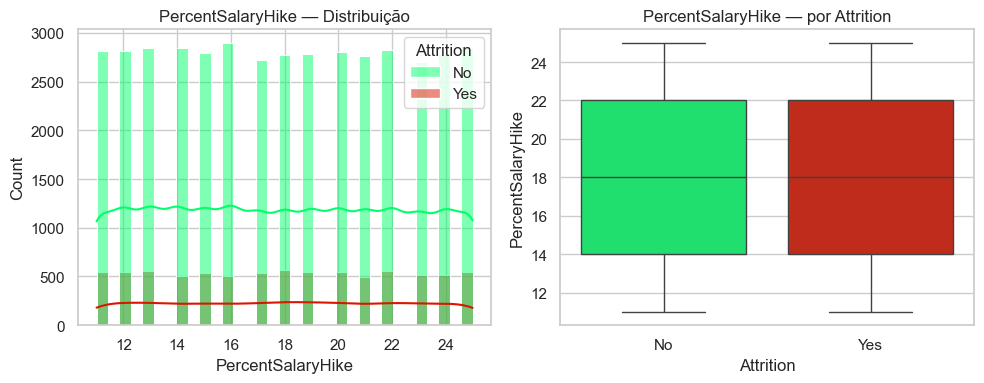

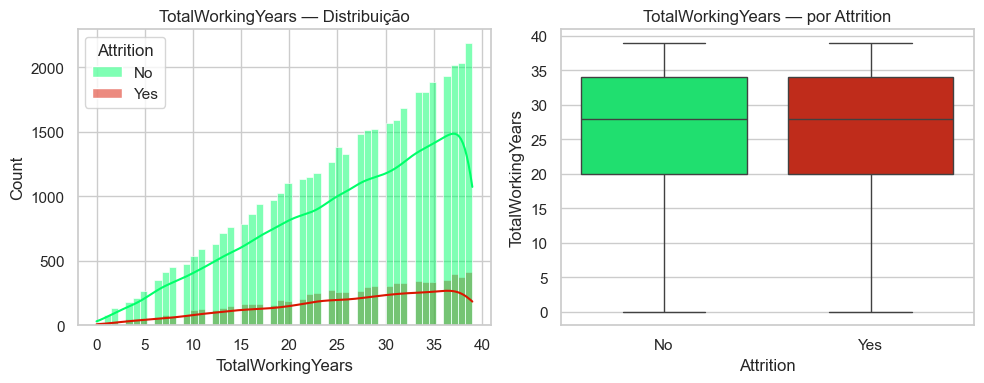

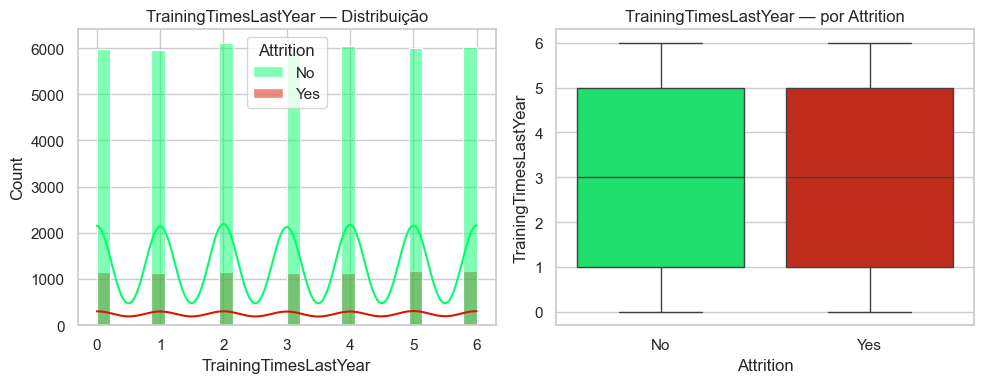

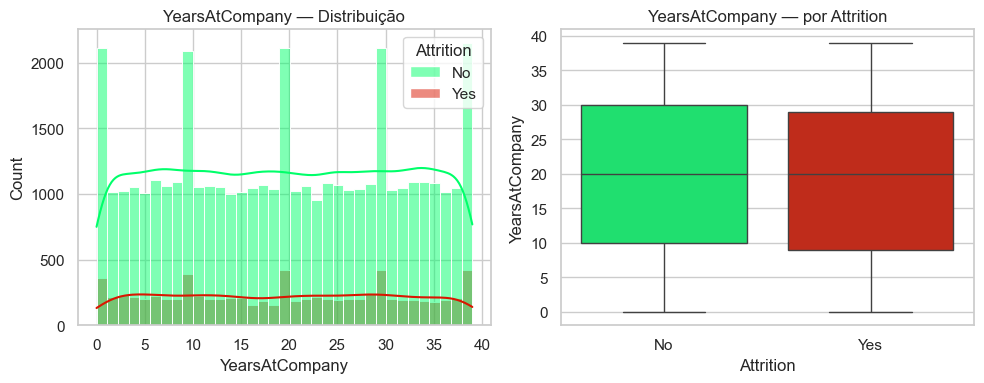

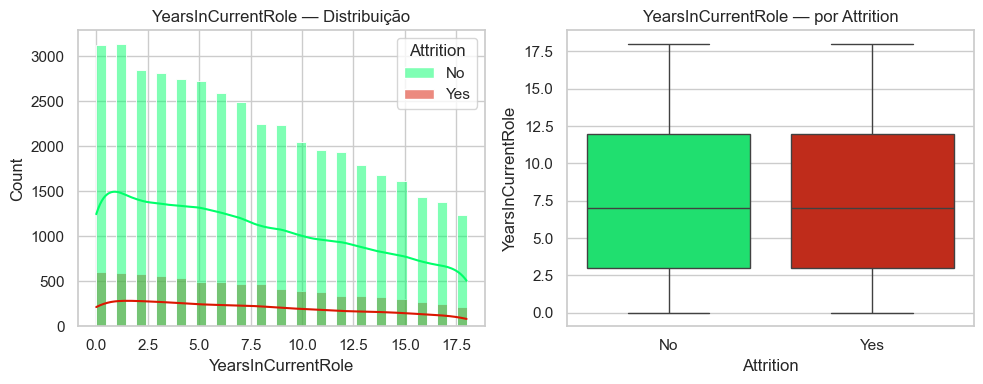

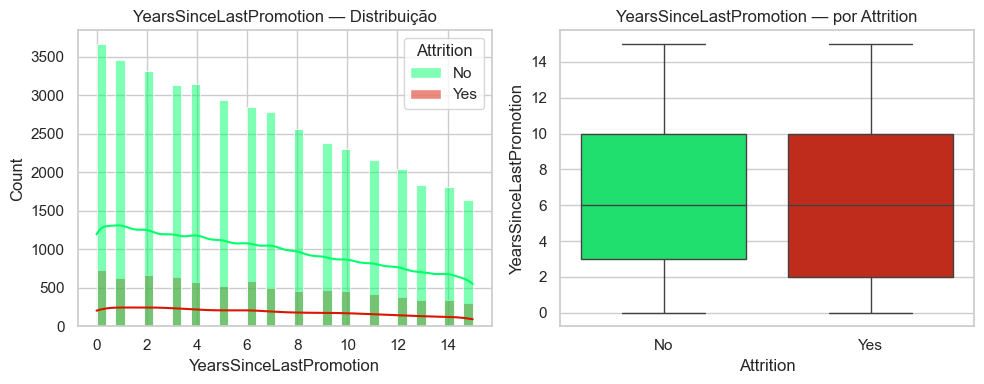

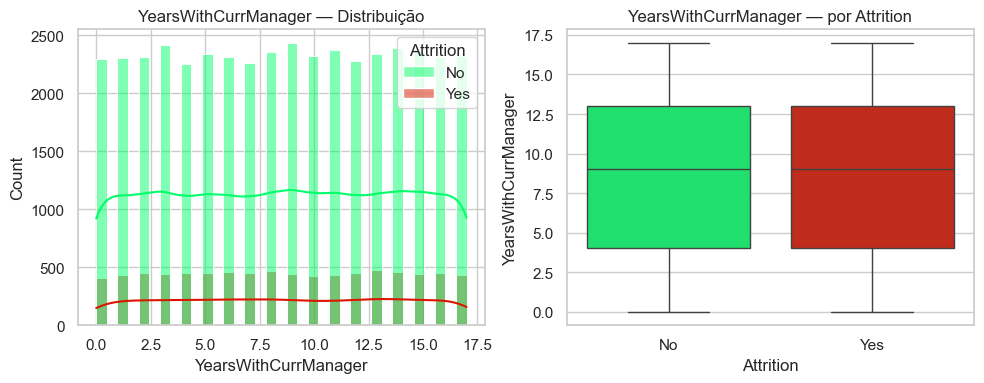

In [18]:
analise_variaveis_continuas(df_sample, num_continuas)

## Análise Variáveis Contínuas

### Age
- Histograma: curvas sobrepostas, Yes distribuído uniformemente em todas as idades
- Boxplot: medianas praticamente iguais (~40 anos), IQR similar entre grupos
- Análise: Age não diferencia quem sai de quem fica nesse dataset
- Status: Pendente validação estatística

### DailyRate

- Histograma: As curvas estão sobrepostas e estão distribuidas uniformemente.
- Boxplot: As medianas estão praticamente iguais, e IQR são similadres também
- Análise: DailyRate não diferencia quem sai de quem fica
- Status: Pendente validação estatística

### DistanceFromHome

- Histograma: As curvas estão sobrepostas e estão distribuidas uniformemente.
- Boxplot: As medianas estão praticamente iguais, e IQR são similadres também
- Análise: DistanceFromHome não diferencia quem sai de quem fica
- Status: Pendente validação estatística

### HourlyRate

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: Os IQRs são similares e as medianas estão praticamente idênticas.
- Análise: HourlyRate não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### MonthlyIncome

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: MonthlyIncome não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### MonthlyRate

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: MonthlyRate não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### NumCompaniesWorked

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: NumCompaniesWorked não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### PercentSalaryHike

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: PercentSalaryHike não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### TotalWorkingYears

- Histograma: As curvas estão sobrepostas. A distribuição é crescente (não em sino), mas Yes e No mantêm a mesma proporção em todas as faixas.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: TotalWorkingYears não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### TrainingTimesLastYear

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: TrainingTimesLastYear não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### YearsAtCompany

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas e os IQRs estão muito próximos entre os grupos.
- Análise: YearsAtCompany não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### YearsInCurrentRole

- Histograma: As curvas estão sobrepostas e seguem o mesmo formato decrescente.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: YearsInCurrentRole não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### YearsSinceLastPromotion

- Histograma: As curvas estão sobrepostas e seguem o mesmo formato decrescente.
- Boxplot: As medianas estão praticamente iguais; o IQR do grupo Yes é levemente menor que o do grupo No.
- Análise: YearsSinceLastPromotion não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### YearsWithCurrManager

- Histograma: As curvas estão sobrepostas e distribuídas de forma uniforme.
- Boxplot: As medianas estão praticamente iguais, e os IQRs são similares também.
- Análise: YearsWithCurrManager não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

## 3.2 - Distribuição das Variáveis Ordinais

In [19]:
# Cria pasta se não existir
output_dir = "../reports/distribuicao_variaveis_ordinais"
os.makedirs(output_dir, exist_ok=True)

def analise_variaveis_ordinais(df_amostra, df_completo, variaveis):

    for col in variaveis:

        # Cria uma figura para cada variável
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # --- Gráfico 1: Contagem absoluta ---
        sns.countplot(
            data=df_amostra,
            x=col,
            hue='Attrition',
            ax=axes[0],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}
        )
        axes[0].set_title(f'{col} — Contagem Absoluta')
        axes[0].legend(title='Attrition')

        # --- Gráfico 2: Taxa de Attrition ---
        prop = (
            df_completo.groupby(col)['AttritionFlag']
            .mean()
            .reset_index()
        )

        sns.barplot(
            data=prop,
            x=col,
            y='AttritionFlag',
            ax=axes[1],
            color='#e74c3c'
        )

        axes[1].set_title(f'{col} — % de Attrition por categoria')
        axes[1].set_ylabel('Taxa de Attrition')
        axes[1].axhline(
            df_completo['AttritionFlag'].mean(),
            color='gray',
            linestyle='--',
            linewidth=1,
            label='Média geral'
        )
        axes[1].legend()

        plt.tight_layout()

        plt.savefig(
            f"{output_dir}/{col}.png",
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

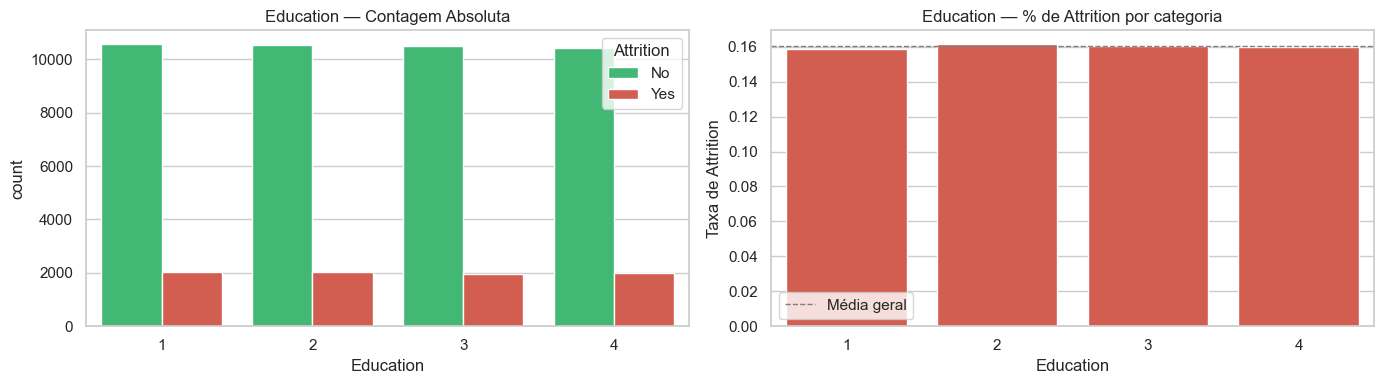

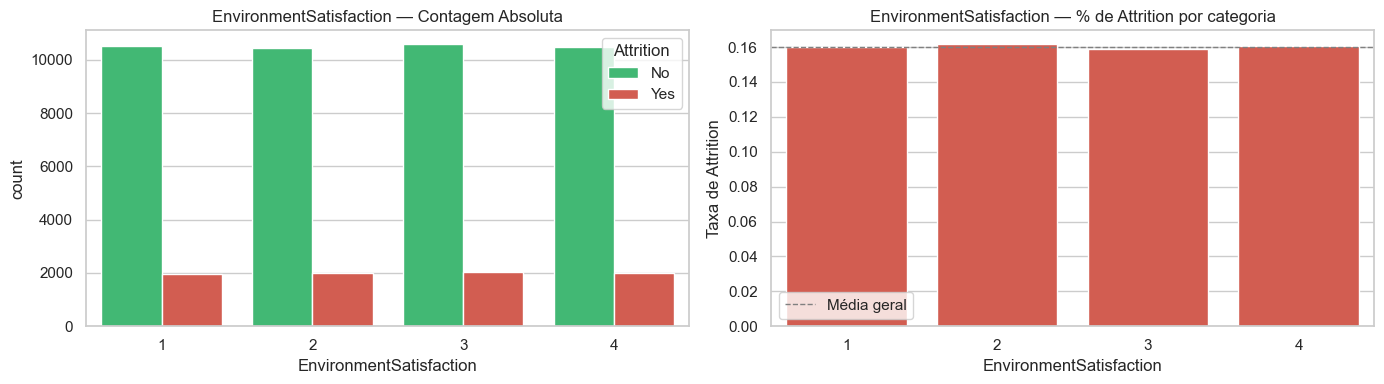

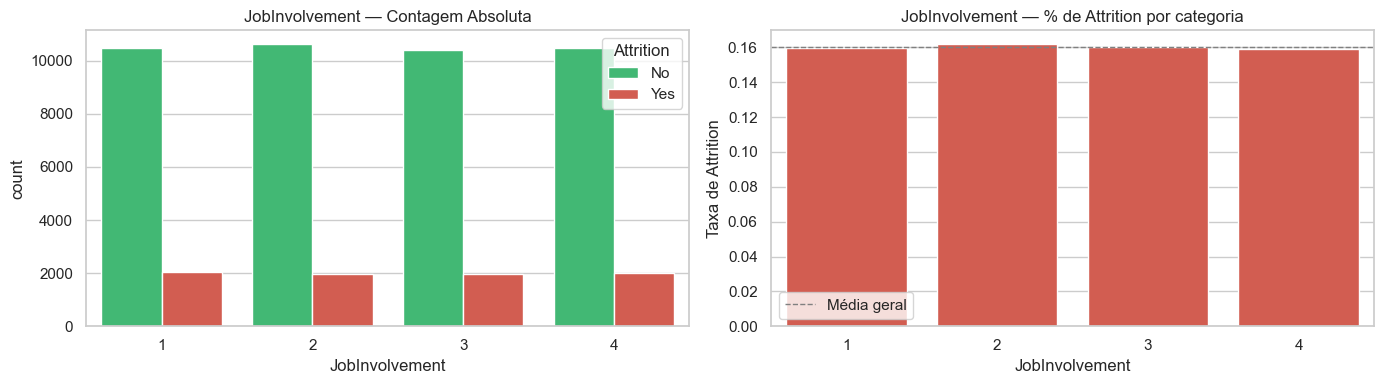

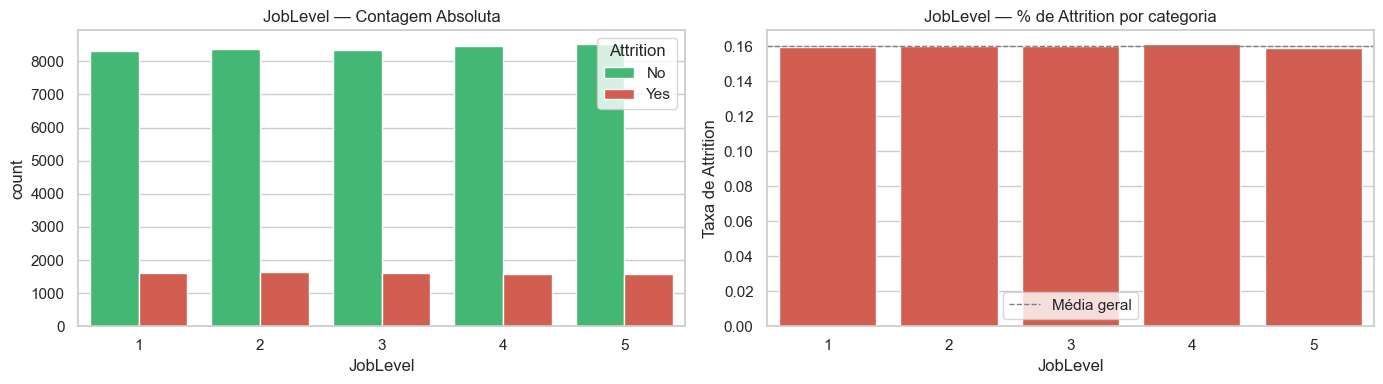

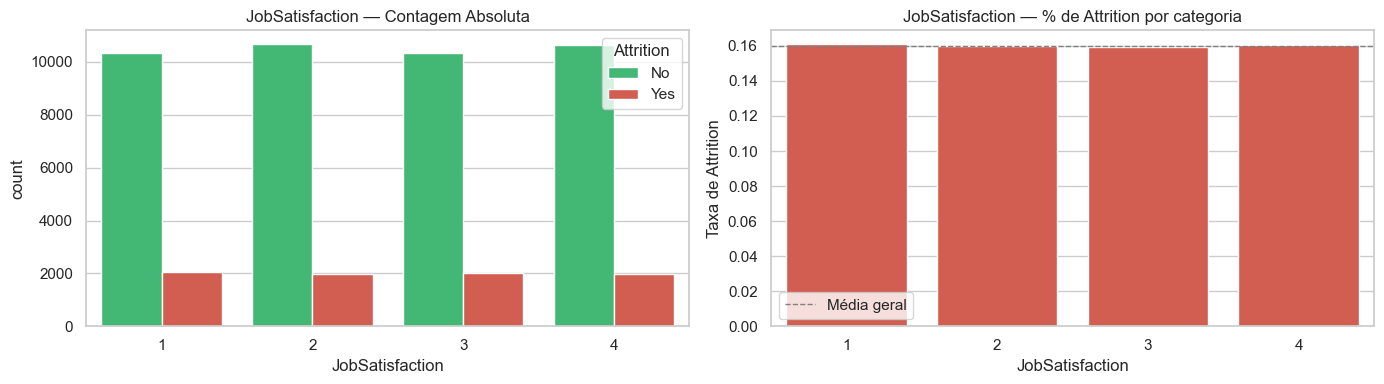

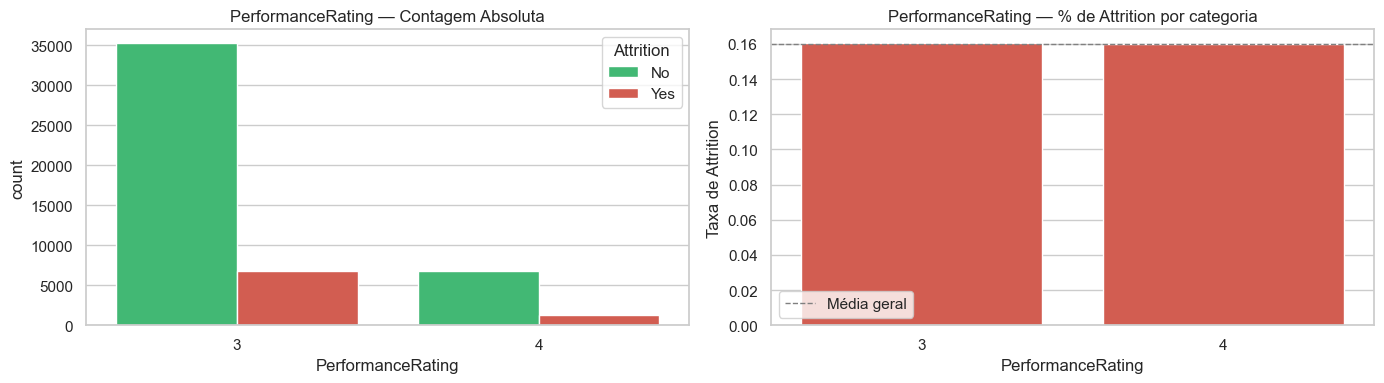

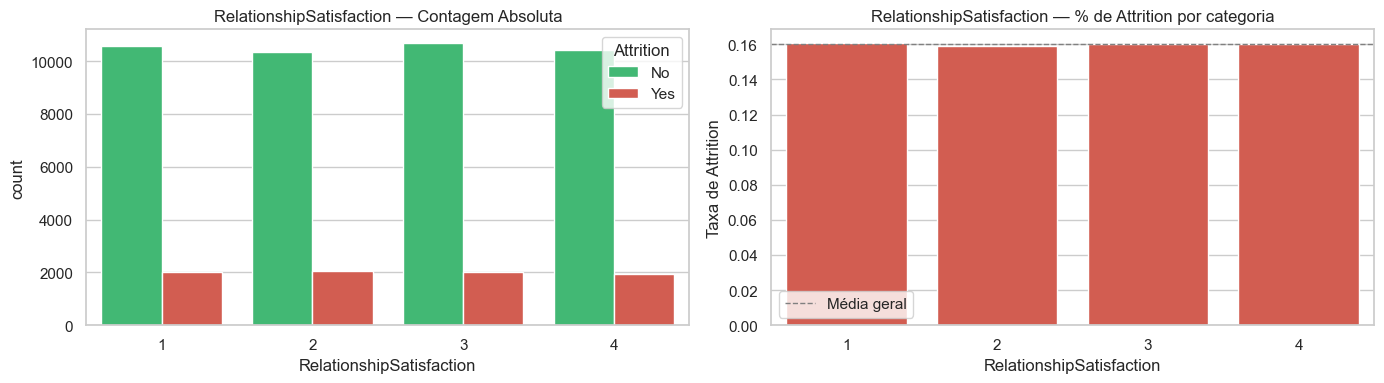

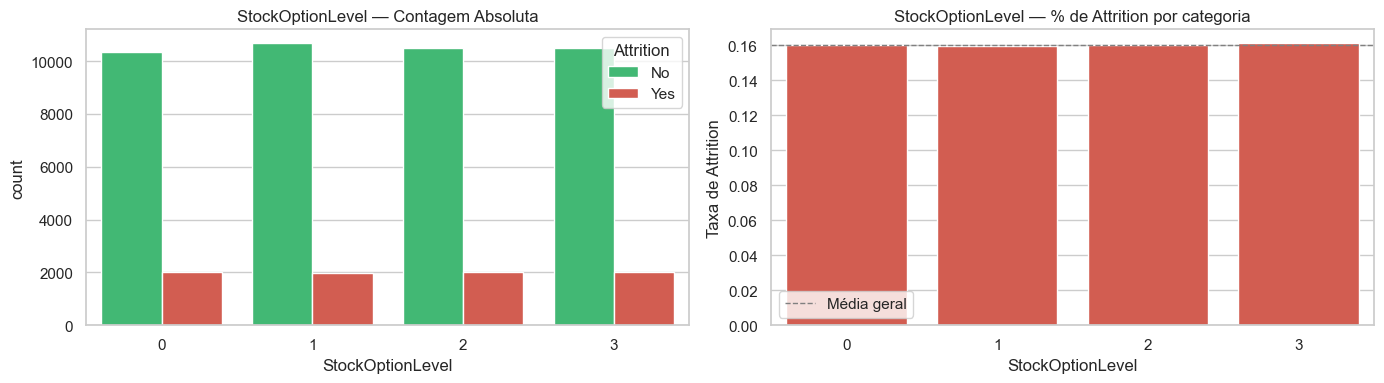

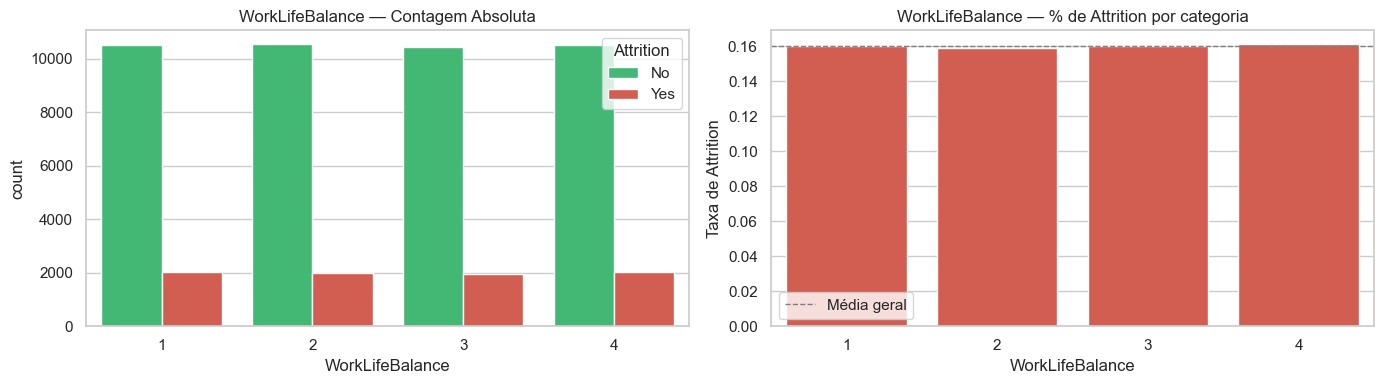

In [20]:
analise_variaveis_ordinais(df_sample, df_eda, num_ordinais)

## Análise Variáveis Ordinais

### Education

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 4).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: Education não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### EnvironmentSatisfaction

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 4).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: EnvironmentSatisfaction não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### JobInvolvement

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 4).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: JobInvolvement não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### JobLevel

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 5).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: JobLevel não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### JobSatisfaction

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 4).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: JobSatisfaction não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### PerformanceRating

- Contagem absoluta: distribuição bastante desigual entre as categorias (3 concentra a grande maioria dos registros, 4 é minoria); a variável possui apenas 2 categorias presentes no dataset.
- Taxa de Attrition: ambas as categorias (3 e 4) têm taxa ~ 16%, igual à média geral.
- Análise: PerformanceRating não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### RelationshipSatisfaction

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 4).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: RelationshipSatisfaction não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### StockOptionLevel

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (0 a 3).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: StockOptionLevel não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

### WorkLifeBalance

- Contagem absoluta: proporção Yes/No visualmente igual em todas as categorias (1 a 4).
- Taxa de Attrition: todas as categorias têm taxa ~ 16%, igual à média geral.
- Análise: WorkLifeBalance não diferencia quem sai da empresa de quem permanece.
- Status: Pendente validação estatística

## 3.3 - Distribuição das Variáveis Categóricas

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cria pasta se não existir
output_dir = "../reports/distribuicao_variaveis_categoricas"
os.makedirs(output_dir, exist_ok=True)

def analise_variaveis_categoricas(df_amostra, df_completo, variaveis):

    for col in variaveis:

        # Cria uma figura para cada variável
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # --- Gráfico 1: Contagem absoluta ---
        sns.countplot(
            data=df_amostra,
            x=col,
            hue='Attrition',
            ax=axes[0],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}
        )

        axes[0].set_title(f'{col} — Contagem Absoluta')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].legend(title='Attrition')

        # --- Gráfico 2: Taxa de Attrition por categoria ---
        prop = (
            df_completo.groupby(col)['AttritionFlag']
            .mean()
            .sort_values(ascending=False)
            .reset_index()
        )

        sns.barplot(
            data=prop,
            x=col,
            y='AttritionFlag',
            ax=axes[1],
            color='#e74c3c'
        )

        axes[1].set_title(f'{col} — % de Attrition por categoria')
        axes[1].set_ylabel('Taxa de Attrition')
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].axhline(
            df_completo['AttritionFlag'].mean(),
            color='gray',
            linestyle='--',
            linewidth=1,
            label='Média geral'
        )
        axes[1].legend()

        plt.tight_layout()

        plt.savefig(
            f"{output_dir}/{col}.png",
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

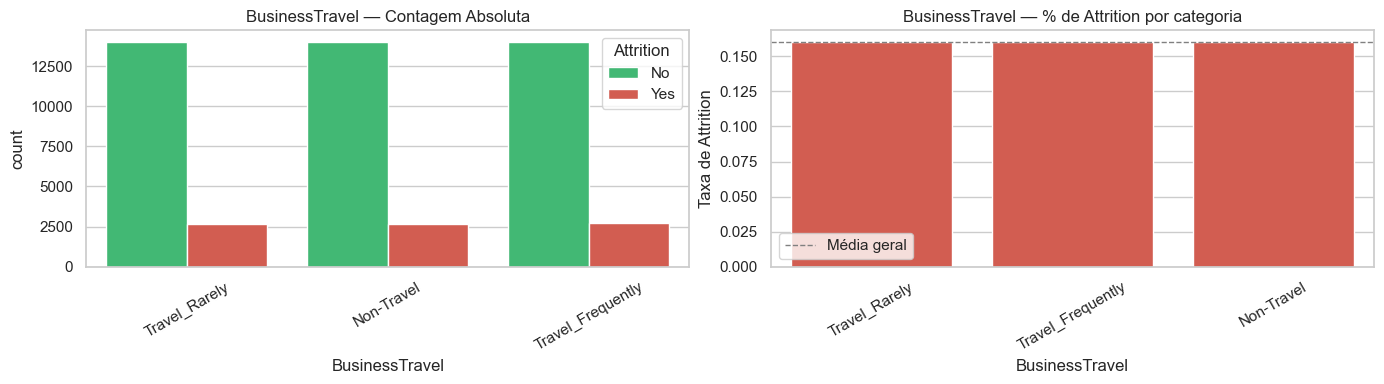

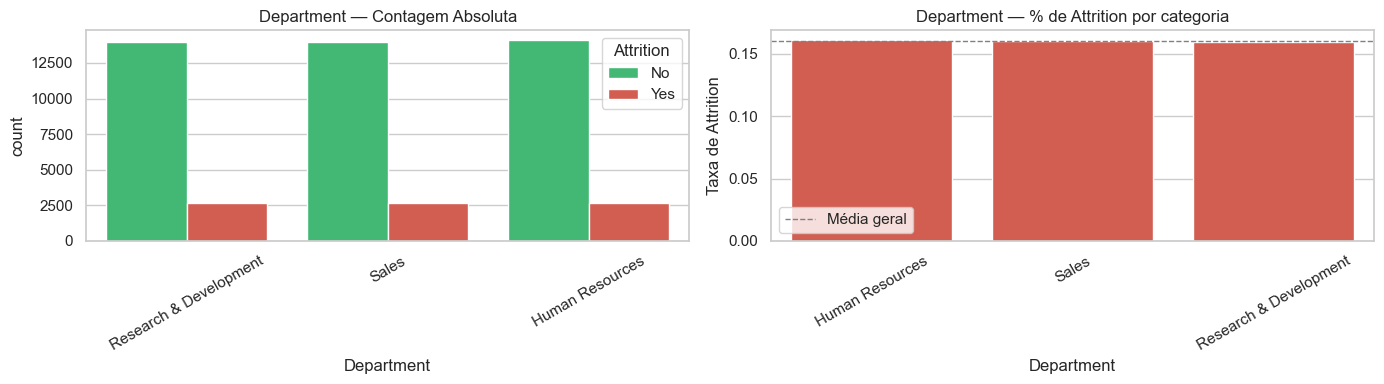

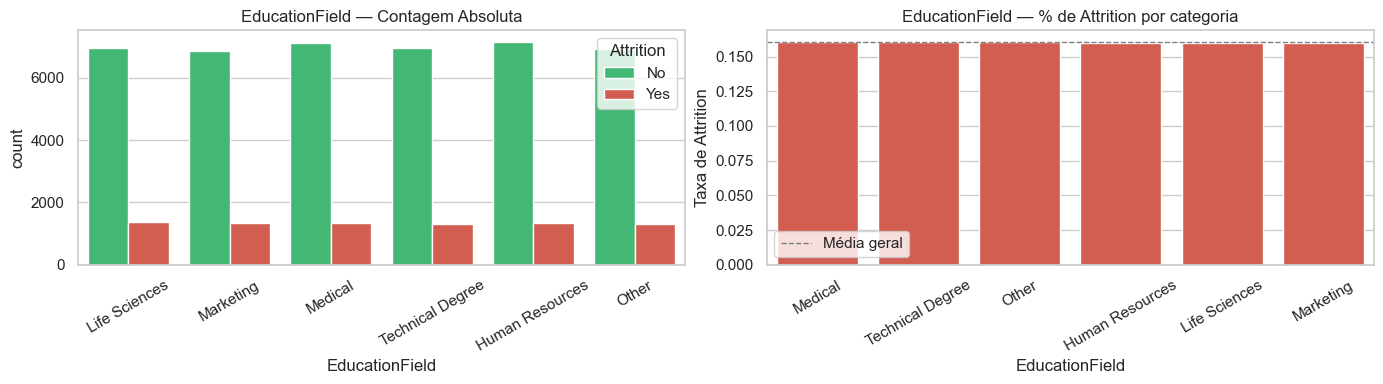

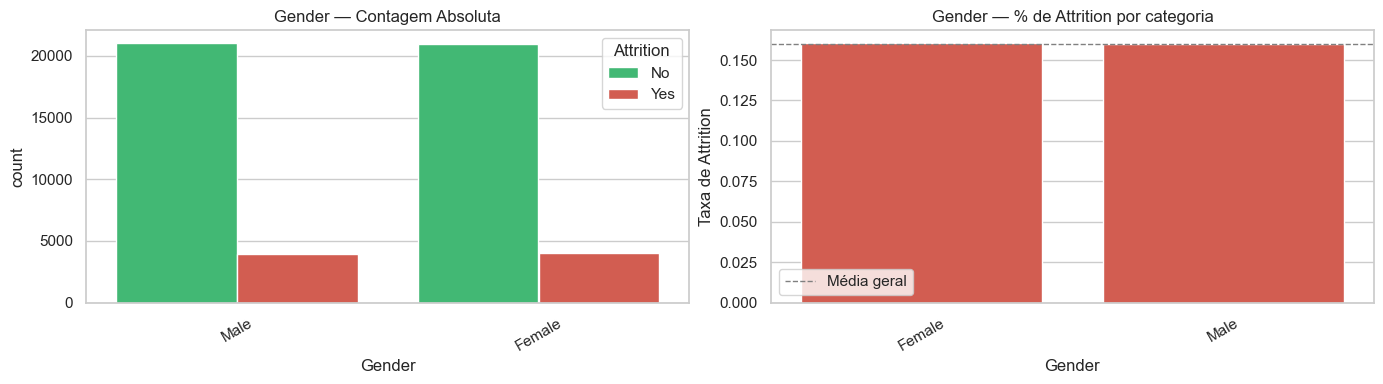

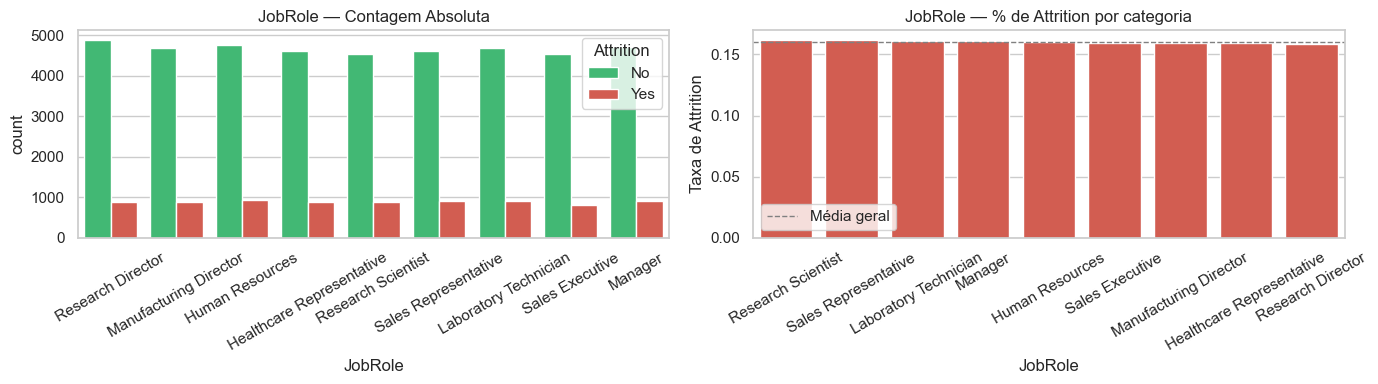

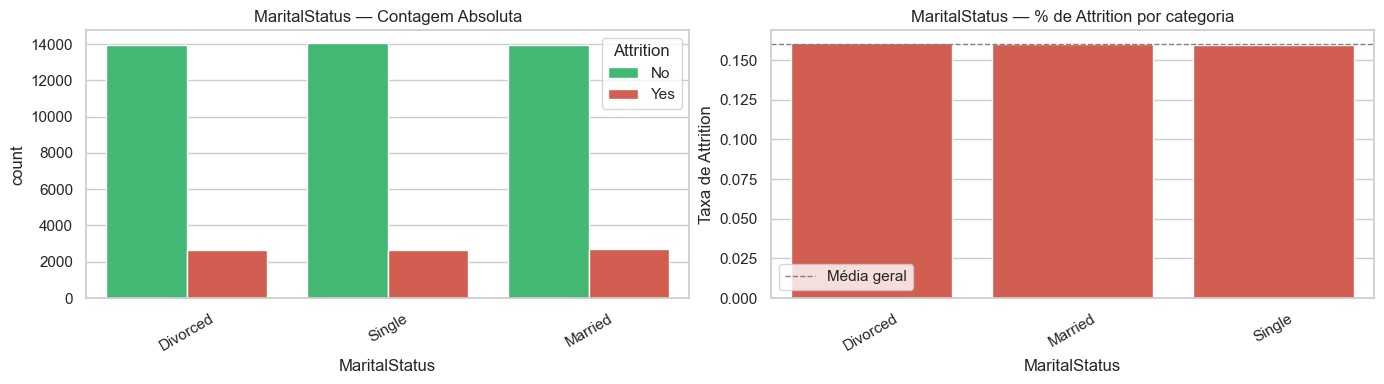

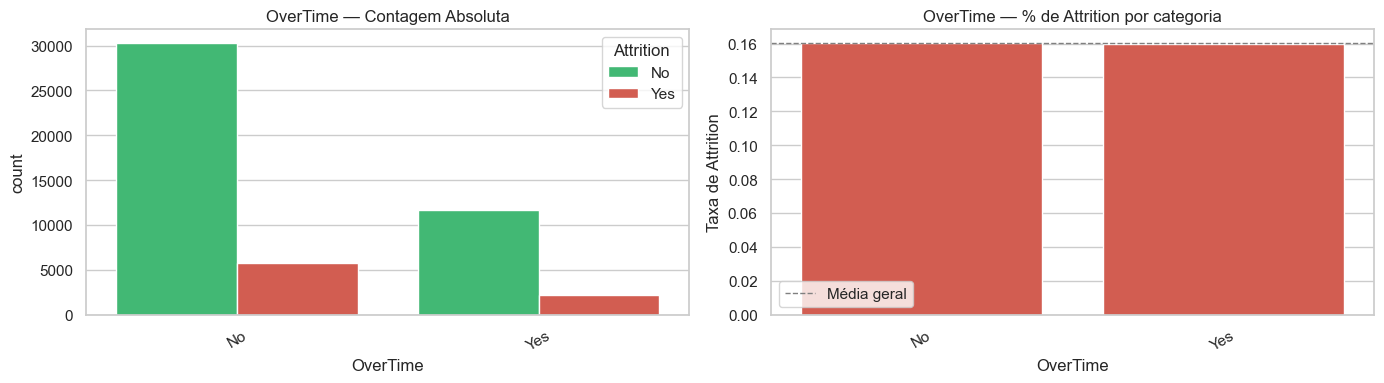

In [22]:
analise_variaveis_categoricas(df_sample, df_eda, cat_cols)

## Análise Variáveis Categóricas

### BusinessTravel

- Contagem Absoluta: Proporção igual para todas as categorias
- Taxa de Attrition: Todas as categorias possuem as mesmas taxas em relação à média.
- Análise: Visualmente a variável BusinessTravel não tem relação com attrition
- Status: Pendente validação estatística

### Department
- Contagem Absoluta: Proporção igual para todas as categorias
- Taxa de Attrition: Todas as categorias possuem as mesmas taxas em relação à média.
- Análise: Visualmente a variável Department não tem relação com attrition
- Status: Pendente validação estatística

### EducationField
- Contagem Absoluta: Proporção igual para todas as categorias
- Taxa de Attrition: Todas as categorias possuem as mesmas taxas em relação à média.
- Análise: Visualmente a variável EducationField não tem relação com attrition
- Status: Pendente validação estatística


### Gender
- Contagem Absoluta: Proporção igual para todas as categorias
- Taxa de Attrition: Todas as categorias possuem as mesmas taxas em relação à média.
- Análise: Visualmente a variável Gender não tem relação com attrition
- Status: Pendente validação estatística

### JobRole
- Contagem Absoluta: A proporção é levemente divergente para algumas categorias, mas mesmo assim ainda bem próxima uma da outra, o que indica que a variável pode estar relacionada com attrition ou seja apenas ruído.
- Taxa de Attrition: Algumas categorias estão levemente acima e levemente abaixo da média de attrition
- Análise: Visualmente a variável JobRole pode levemente identificar categorias que tendem a entrar em attrition
- Status: Pendente validação estatística


### MaritalStatus
- Contagem Absoluta: Proporção igual para todas as categorias
- Taxa de Attrition: Todas as categorias possuem as mesmas taxas em relação à média.
- Análise: Visualmente a variável MaritalStatus não tem relação com attrition
- Status: Pendente validação estatística

### OverTime
- Contagem Absoluta: A proporção visual de Yes/No parece diferente entre as categorias à primeira vista, mas isso se deve à diferença no VOLUME
total de cada grupo (muito mais pessoas não fazem hora extra do que fazem), não a uma diferença real na taxa de attrition.
- Taxa de Attrition: Ambas as categorias (No e Yes) têm taxa praticamente igual à média geral (~16%), sem desvio visível.
- Análise: Visualmente, OverTime não diferencia quem sai da empresa de quem permanece neste dataset.
- Status: Pendente validação estatística

## Conclusões sobre as análises visuais

Até o momento, observamos que nenhuma variável mostrou diferença visual clara que tem correlação com attrition. Mas antes de confiarmos nossas hipóteses, é necessário realizar uma validação estatística e garantir
que os números das variáveis são significantes ou não.

# 4. Análise estatística das variáveis

### Testes U de Mann-Whitney e Qui-Quadrado

Neste momento é realizado testes para confirmar estatísticamente o que observamos na seção anterior nos gráficos da Análise Exploratória. A partir desses testes, conseguimos ver realmente se tem ou não relação com Attrition.

O teste U de Mann-Whitney é um teste estatístico usado para comparar dois grupos independentes (Yes, No). Ele pode ser usado para dados que não seguem uma distribuição normal e servem para dados contínuos e ordinais pois realiza o seu cálculo com base em ranks e soma dos grupos, o que é ideial para as variáveis do nosso dataset.

O teste Qui-Quadrado (Chi-Square) é um teste estatístico usado para verificar se existe associação entre duas variáveis categóricas. Ele compara a frequência observada nos dados (o que realmente aconteceu) com a frequência esperada (o que aconteceria se as variáveis não tivessem relação nenhuma). Quanto maior a diferença entre o observado e o esperado, maior a evidência de que existe uma associação real entre as variáveis. É o teste ideal para as variáveis categóricas do nosso dataset (BusinessTravel, Department, Gender, etc.) pois trabalha com categorias, diferente do Mann-Whitney que trabalha com ranks de valores numéricos.

## 4.1 Mann-Whitney

In [23]:
vars_numericas_ordinais = num_continuas + num_ordinais

resultados_mw = []

for col in vars_numericas_ordinais:
    grupo_yes = df_eda[df_eda['Attrition'] == 'Yes'][col]
    grupo_no  = df_eda[df_eda['Attrition'] == 'No'][col]

    stat, p_value = mannwhitneyu(grupo_yes, grupo_no, alternative='two-sided')

    resultados_mw.append({
        'variavel': col,
        'p_value': p_value,
        'significante': p_value < 0.05
    })

df_resultados_mw = pd.DataFrame(resultados_mw).sort_values('p_value')
df_resultados_mw

,variavel,p_value,significante
11,YearsInCurrentRole,0.039388,True
9,TrainingTimesLastYear,0.127936,False
6,NumCompaniesWorked,0.158392,False
8,TotalWorkingYears,0.244082,False
14,Education,0.246807,False
10,YearsAtCompany,0.256562,False
21,StockOptionLevel,0.303037,False
1,DailyRate,0.308521,False
22,WorkLifeBalance,0.335174,False
3,HourlyRate,0.371675,False


### 4.2 Qui-Quadrado (categóricas)

In [24]:
resultados_chi2 = []

for col in cat_cols:
    tabela_contingencia = pd.crosstab(df_eda[col], df_eda['Attrition'])

    chi2, p_value, dof, expected = chi2_contingency(tabela_contingencia)

    resultados_chi2.append({
        'variavel': col,
        'p_value': p_value,
        'significante': p_value < 0.05
    })

df_resultados_chi2 = pd.DataFrame(resultados_chi2).sort_values('p_value')
df_resultados_chi2

,variavel,p_value,significante
5,MaritalStatus,0.232791,False
1,Department,0.353431,False
6,OverTime,0.394338,False
4,JobRole,0.439206,False
3,Gender,0.685681,False
0,BusinessTravel,0.851303,False
2,EducationField,0.908798,False


### **Conclusão**

Das 30 variáveis originais do dataset:
- 29 não apresentaram significância estatística (p > 0.05)
- 1 apresentou significância relevante (YearsInCurrentRole, p = 0.039) porém com diferença desprezível entre os grupos (confirmado posteriormente pela correlação de apenas 0.002 com o target)

A EDA visual se mostrou altamente confiável: 96,7% das hipóteses visuais foram confirmadas estatisticamente (29 de 30 variáveis).

Nenhuma variável original, isoladamente, demonstra relação prática relevante com o Attrition neste dataset. Esse resultado reforça a importância da etapa de Feature Engineering, onde criaremos variáveis derivadas e interações capazes de capturar padrões que as variáveis originais, analisadas individualmente, não conseguem revelar.

# 5. Análise de Correlações

### Por que Spearman e não Pearson?

Optamos pela correlação de Spearman pois:
1. Trabalha com ranks, sendo adequada para variáveis ordinais (JobSatisfaction, Education, etc.)
2. Não exige distribuição normal dos dados (nossas variáveis apresentam distribuição uniforme)
3. Mantém consistência metodológica com o teste de Mann-Whitney (ambos baseados em ranks)

In [25]:
# # Variáveis para a matriz de correlação (numéricas + ordinais + target)
# vars_correlacao = num_continuas + num_ordinais + ['AttritionFlag']

# # Matriz de correlação usando Spearman
# matriz_corr = df_eda[vars_correlacao].corr(method='spearman')

# # Heatmap
# plt.figure(figsize=(16, 12))
# sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', center=0,
#             vmin=-1, vmax=1, square=True, linewidths=0.5)

# plt.title('Matriz de Correlação (Spearman) — Variáveis Numéricas/Ordinais')
# plt.tight_layout()
# plt.savefig('../reports/matriz_correlacao.png', dpi=150, bbox_inches='tight')
# plt.show()

# TODO: RETIRAR ESSA CELULAR

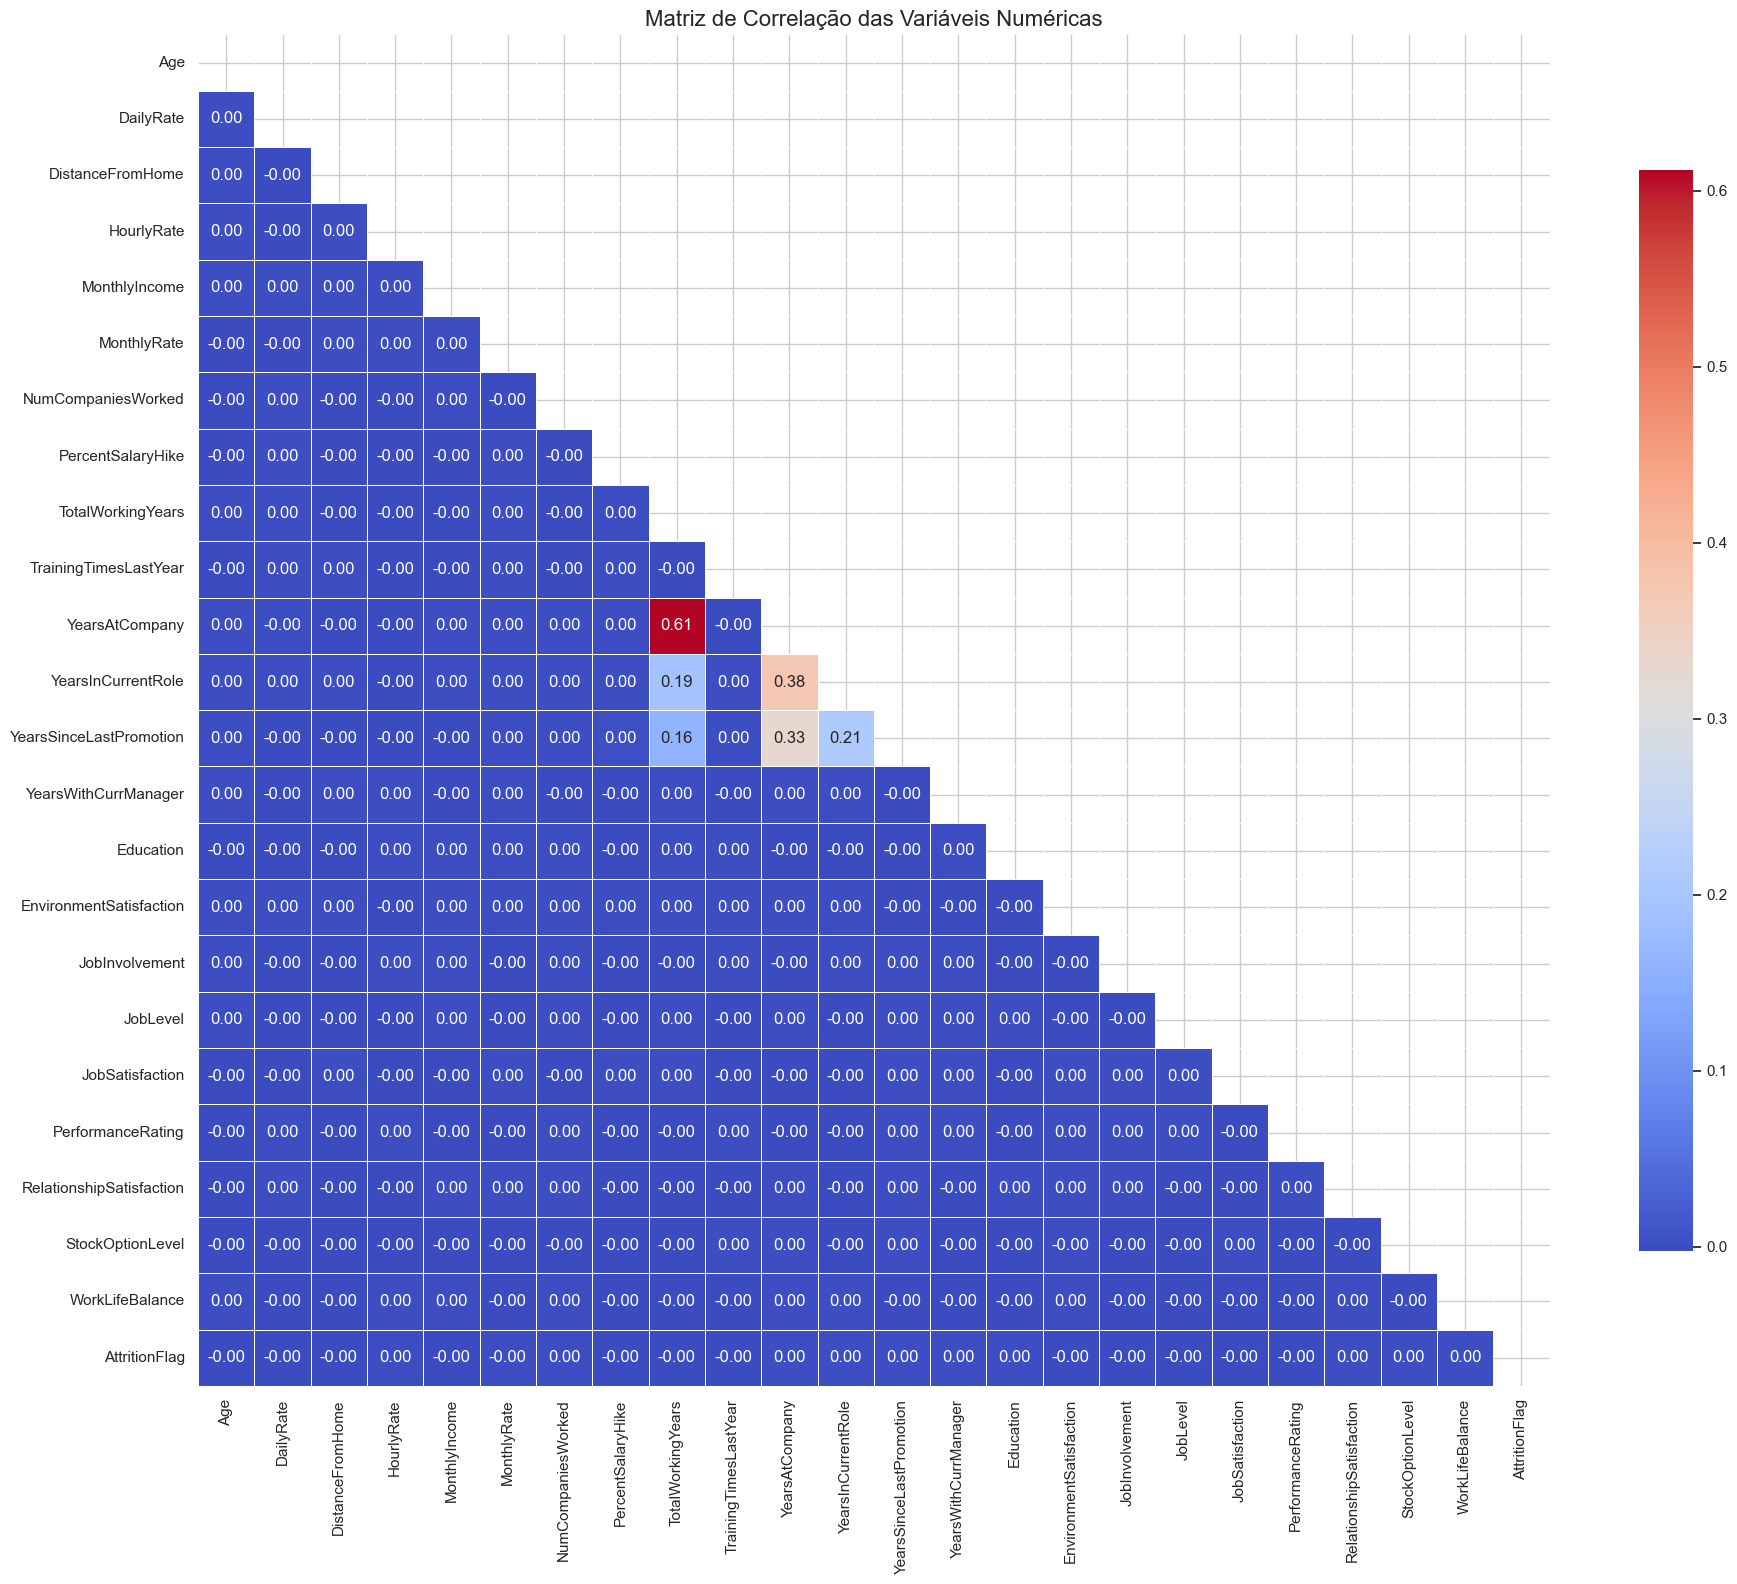

In [26]:
# Matriz de correlação
vars_correlacao = num_continuas + num_ordinais + ['AttritionFlag']
plt.figure(figsize=(20, 16))
correlation_matrix = df_eda[vars_correlacao].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
corr_target = correlation_matrix['AttritionFlag'].drop('AttritionFlag').sort_values(key=abs, ascending=False)
corr_target

YearsInCurrentRole          0.001923
TrainingTimesLastYear      -0.001522
NumCompaniesWorked          0.001410
TotalWorkingYears          -0.001205
Education                   0.001158
YearsAtCompany              0.001134
StockOptionLevel            0.001029
DailyRate                  -0.001018
WorkLifeBalance             0.000964
HourlyRate                  0.000892
MonthlyIncome              -0.000868
PercentSalaryHike          -0.000807
YearsSinceLastPromotion     0.000793
JobInvolvement             -0.000776
DistanceFromHome           -0.000732
JobSatisfaction            -0.000650
PerformanceRating          -0.000516
EnvironmentSatisfaction    -0.000303
JobLevel                   -0.000294
RelationshipSatisfaction    0.000280
YearsWithCurrManager        0.000174
Age                        -0.000090
MonthlyRate                -0.000011
Name: AttritionFlag, dtype: float64

In [27]:
def high_corr_pairs(corr_matrix, threshold=0.70):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) >= threshold:
                pairs.append({
                    "var_1": cols[i],
                    "var_2": cols[j],
                    "correlacao": corr_value
                })
    return pd.DataFrame(pairs).sort_values("correlacao", key=lambda s: s.abs(), ascending=False)

vars_correlacao = num_continuas + num_ordinais
high_corr_pairs(df_eda[vars_correlacao].corr(method="spearman"), threshold=0.10)

,var_1,var_2,correlacao
0,TotalWorkingYears,YearsAtCompany,0.599051
3,YearsAtCompany,YearsInCurrentRole,0.373085
4,YearsAtCompany,YearsSinceLastPromotion,0.325132
5,YearsInCurrentRole,YearsSinceLastPromotion,0.223528
1,TotalWorkingYears,YearsInCurrentRole,0.157276
2,TotalWorkingYears,YearsSinceLastPromotion,0.130316


### **Multicolinearidade**

Multicolineariedade é quando duas ou mais variáveis medem praticamente a mesma coisa, tendo praticamente as mesmas informações separadamente.

**Por que isso é um problema para os modelos?**

Por medirem praticamente a mesma informação, o modelo pode ficar confuso ao tentar atribuir pesos para essas variáveis e os coeficientes ficam instáveis e difíceis de interpretar.

### **Mapa de Calor**

Podemos análisar que a maioria das variáveis estão com a correlação próxima de zero, mas existe um bloco de variáveis que se destacam.

Variáveis de tempo com correlação entre si:

- TotalWorkingYears  <-> YearsAtCompany
- YearsAtCompany     <-> YearsInCurrentRole
- YearsAtCompany     <-> YearsSinceLastPromotion
- YearsInCurrentRole <-> YearsSinceLastPromotion
- TotalWorkingYears  <-> YearsInCurrentRole
- TotalWorkingYears  <-> YearsSinceLastPromotion


Para o negócio, essa lógica faz muito sentido pois um funcionário com 20 anos de empresa (YearsAtCompany alto):
- Provavelmente tem muitos anos de carreira (TotalWorkingYears alto) — correlação de 0.5991
- Provavelmente tem vários anos no cargo atual (YearsInCurrentRole alto) — correlação de 0.3731
- Pode ter mais tempo desde a última promoção (YearsSinceLastPromotion alto) — correlação de 0.3251

São variáveis que naturalmente andam juntas e medem aspectos diferentes, mas relacionados, do mesmo conceito: tempo de empresa/carreira.

YearsAtCompany é a variável central desse bloco, aparecendo nos 3 pares de maior correlação do dataset. Nenhum par ultrapassa 0.70 (nível crítico), portanto a multicolinearidade é moderada e será considerada na etapa de Feature Engineering.

### **Planejamento**

Avaliar a possibilidade de combinar essas variáveis em construir novas features para reduzir a multicolineariedade e constribuir para o Feature Engineering.

# Consolidação dos insights

## O que descobrimos ao longo da Análise Exploratória

1. EDA Visual (gráficos)
   -> nenhuma variável mostrou diferença visual entre Yes e No
   -> contínuas, ordinais e categóricas: todas sobrepostas

2. Validação Estatística (Mann-Whitney / Qui-Quadrado)
   -> 29 de 30 variáveis: sem significância estatística
   -> 1 variável (YearsInCurrentRole): significância pequena (p=0.039), provavelmente artefato do volume do dataset

3. Correlação com o Target (Spearman)
   -> todas as correlações entre -0.002 e +0.002
   -> praticamente zero — nenhuma relação individual relevante

4. Correlação entre Features (multicolinearidade)
   -> bloco de correlação moderada entre variáveis de tempo (YearsAtCompany, TotalWorkingYears, YearsInCurrentRole, YearsSinceLastPromotion)
   -> YearsAtCompany como variável central do bloco contendo correlção mais forte

## Insights de Negócio — Conclusão da EDA

### Insight 1 — Variáveis individuais não explicam o Attrition

Nenhuma das 30 variáveis do dataset, apresenta relação relevante com o Attrition.
Isso significa que a decisão de um funcionário sair da empresa NÃO é explicada por um único fator como salário, idade, ou satisfação, mas provavelmente por uma combinação de fatores.

Implicação para o RH: políticas genéricas focadas em um único aspecto por exemplo: aumentar salários para reduzir attrition, provavelmente não seria eficaz. A abordagem precisa ser atacada em mais de um aspecto.

### Insight 2 — Feature Engineering é essencial

Como as variáveis originais isoladamente não explicam o Attrition, a etapa de Feature Engineering será decisiva para tentativa de sucesso do modelo. A criação de variáveis derivadas (interações, proporções, agrupamentos) pode capturar padrões que as variáveis originais sozinhas não mostram.

É necessário a criação de novas features para melhorarmos as relações das variáveis com attrition e chegar em um modelo que consiga realizar previsões assertivas.

### Insight 3 — Multicolinearidade moderada entre variáveis de tempo

Existem algumas variáveis com correlação moderada entre YearsAtCompany, TotalWorkingYears, YearsInCurrentRole e YearsSinceLastPromotion. Isso será tratado no Feature Engineering,
potencialmente combinando essas variáveis em features derivadas que reduzam a redundância e gerem novas informações.

### Insight 4 — As metodologias das análises

As três camadas de evidência gráfica, estatística e correlacional, convergem para a mesma conclusão em 96,7% dos casos (29 de 30 variáveis). Isso demonstra que a metodologia adotada na EDA é confiável e que as conclusões são sólidas.